In [1]:
from google.colab import files
uploaded = files.upload()

Saving contractions.py to contractions.py
Saving dataset.xlsx to dataset.xlsx
Saving htmlstripper.py to htmlstripper.py
Saving model_evaluation_utils.py to model_evaluation_utils.py
Saving text_normalizer.py to text_normalizer.py


In [2]:
!pip install ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00


In [3]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# 1) DATASET AND DATA UNDERSTANDING

* Upload dataset
* Removing duplicates
* Balance analysis
* Balanced dataset

In [4]:
import pandas as pd
import numpy as np

# reproducibility
RANDOM_STATE = 42  #NEW#
np.random.seed(RANDOM_STATE)  #NEW#

# dataset
original = pd.read_excel('dataset.xlsx')

# casual preview
original.sample(20, random_state=RANDOM_STATE)

# structure check
print(original.info())
print(original.columns)

# duplicated sentences
duplicates = original[original.duplicated(subset='Sentence', keep=False)]
print(f"Duplicated sentences: {len(duplicates)}")

# unique sentences
num_unique = original['Sentence'].nunique()
print(f"Unique sentences: {num_unique}")

# remove duplicates
dataset_unique = (
    original
    .drop_duplicates(subset='Sentence', keep='first')
    .reset_index(drop=True)
)

print(f"Original rows: {len(original)}")
print(f"Rows after duplicate removal: {len(dataset_unique)}")

# class distribution
label_counts = dataset_unique['Sentiment'].value_counts()
label_percentages = dataset_unique['Sentiment'].value_counts(normalize=True) * 100

label_stats = pd.DataFrame({
    'count': label_counts,
    'percentage': label_percentages.round(2)
})

print(label_stats)

# unbalanced class analysis
print("Class imbalance ratio:")
print(label_counts / label_counts.min())  #NEW#

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35782 entries, 0 to 35781
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   35782 non-null  object
 1   Sentiment  35782 non-null  object
dtypes: object(2)
memory usage: 559.2+ KB
None
Index(['Sentence', 'Sentiment'], dtype='object')
Duplicated sentences: 4849
Unique sentences: 33283
Original rows: 35782
Rows after duplicate removal: 33283
           count  percentage
Sentiment                   
positive   13426       40.34
neutral    12219       36.71
negative    7638       22.95
Class imbalance ratio:
Sentiment
positive    1.757790
neutral     1.599764
negative    1.000000
Name: count, dtype: float64


## 1.1) Balance and training/test sets

In [5]:
# class separation
positive_df = dataset_unique[dataset_unique['Sentiment'] == 'positive']
neutral_df  = dataset_unique[dataset_unique['Sentiment'] == 'neutral']
negative_df = dataset_unique[dataset_unique['Sentiment'] == 'negative']

# Undersampling classi maggioritarie
positive_sampled = positive_df.sample(n=8000, random_state=RANDOM_STATE)  #SFA#
neutral_sampled  = neutral_df.sample(n=8000, random_state=RANDOM_STATE)   #SFA#

# balanced dataset
dataset_balanced = (
    pd.concat([positive_sampled, neutral_sampled, negative_df])
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(dataset_balanced['Sentiment'].value_counts())

############################################
# stratified training/test sets
############################################

from sklearn.model_selection import train_test_split

sentences  = np.array(dataset_balanced['Sentence'])
sentiments = np.array(dataset_balanced['Sentiment'])

# First division: temporary (training+validation) / test (85/15)
temp_sentences, test_sentences, temp_labels, test_labels = train_test_split(
    sentences,
    sentiments,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=sentiments
)

# Second division: training / validation (70/15 = 85)
train_sentences, val_sentences, train_labels, val_labels = train_test_split(
    temp_sentences,
    temp_labels,
    test_size=0.17647,
    random_state=RANDOM_STATE,
    stratify=temp_labels
)

# Final result: training 70% / validation 15% / test 15%

print("Train distribution:", pd.Series(train_labels).value_counts())
print("Validation distribution:", pd.Series(val_labels).value_counts())
print("Test distribution:",  pd.Series(test_labels).value_counts())

Sentiment
positive    8000
neutral     8000
negative    7638
Name: count, dtype: int64
Train distribution: positive    5600
neutral     5600
negative    5346
Name: count, dtype: int64
Validation distribution: positive    1200
neutral     1200
negative    1146
Name: count, dtype: int64
Test distribution: neutral     1200
positive    1200
negative    1146
Name: count, dtype: int64


# 2) TEST PREPROCESSING

* Shared cleaning
* Two pipelines:
* A) Default ML (TD-IDF and SVM): stopwords and lemmatization
* B) DL (LSTM): minimal tokenization (no lemmatization)


The preprocessing pipelines are model-dependent by design, as different architectures rely on different linguistic assumptions. Applying the same preprocessing to all models would introduce a methodological bias rather than removing it.

Morphological variations may carry sentiment-relevant information, which embeddings and LSTM architectures are able to exploit. Lemmatization is more suitable for frequency-based representations.

In [6]:
import re
import ftfy
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer  #NEW#

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## 2.1) Sentence cleaning (shared)

In [7]:
############################################
# Sentence cleaning (shared)
############################################

def clean_sentence(sentence):
    sentence = ftfy.fix_text(sentence)  #SFA#
    sentence = re.sub(r'http\S+|www\S+', '', sentence)
    sentence = re.sub(r'@\w+', '', sentence)
    sentence = re.sub(r'\$\w+', '', sentence)              #SFA#
    sentence = re.sub(r'\(\w+:\w+\)', '', sentence)        #SFA#
    sentence = re.sub(r'#\w+', '', sentence)
    sentence = re.sub(r'[\|–—…]', '', sentence)
    sentence = re.sub(r'[:;=8][\-~]?[)DPO]', '', sentence)
    return sentence.strip()

# base cleaning
train_clean = np.array([clean_sentence(s) for s in train_sentences])
val_clean  = np.array([clean_sentence(s) for s in val_sentences])
test_clean = np.array([clean_sentence(s) for s in test_sentences])

## 2.2A) Preprocessing: TF-IDF and SVM

In [8]:
import text_normalizer as tn

stop_words = stopwords.words('english')
for w in ['no', 'not', 'but']:
    stop_words.remove(w)  #SFA#

lemmatizer = WordNetLemmatizer()  #NEW#

def preprocess_ml(text):
    tokens = nltk.word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]  #NEW#
    return " ".join(tokens)

train_ml = np.array([preprocess_ml(s) for s in train_clean])
val_ml  = np.array([preprocess_ml(s) for s in val_clean])
test_ml = np.array([preprocess_ml(s) for s in test_clean])

## 2.2B) Preprocessing: LSTM

In [9]:
def preprocess_dl(text):
    tokens = nltk.word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]
    return " ".join(tokens)  #NEW#

train_dl = np.array([preprocess_dl(s) for s in train_clean])
val_dl  = np.array([preprocess_dl(s) for s in val_clean])
test_dl = np.array([preprocess_dl(s) for s in test_clean])

## 2.3) Output check

In [10]:
print("ML example:", train_ml[0])
print("DL example:", train_dl[0])


ML example: unitedhealth stock price target raised cfra
DL example: unitedhealth stock price target raised to from at cfra


The two preprocessing pipelines lead to substantially different textual representations, reflecting the different assumptions of bag-of-words models and sequence-based neural networks.

# 3) TEXT REPRESENTATION

**Objective**: transform the preprocessed text into numerical features to use inside the models.

## 3.1) Bag of Words



In [11]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.3 MB/s eta 0:00:00


In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer #SFA#
from gensim.models import Word2Vec #SFA#
from tensorflow.keras.preprocessing.text import Tokenizer #SFA#
from tensorflow.keras.preprocessing.sequence import pad_sequences #SFA#


# --- Bag of Words (BOW) --- #
cv = CountVectorizer(binary=False, min_df=0.0, max_df=1.0, ngram_range=(1,2)) #SFA#
cv_train_features = cv.fit_transform(train_ml) #NEW# train_ml è la versione preprocessata per ML
cv_val_features = cv.transform(val_ml) #NEW#
cv_test_features = cv.transform(test_ml) #NEW#

print('BOW model:> Train features shape:', cv_train_features.shape,
      ' Test features shape:', cv_val_features.shape) #NEW#

BOW model:> Train features shape: (16546, 141919)  Test features shape: (3546, 141919)


*Output: Bag of Words*

La matrice BoW ha dimensioni **(16.546 × 141.919)**: ogni frase è rappresentata come un vettore
sparso di conteggi su un vocabolario di quasi 142.000 token (unigrammi e bigrammi).

L'uso di `ngram_range=(1,2)` cattura coppie di parole adiacenti come *"stock price"* o
*"net profit"*, che nel dominio finanziario sono spesso più informative dei singoli token.
La matrice è estremamente sparsa: la maggior parte dei valori è zero, il che è tipico di
rappresentazioni bag-of-words su corpus di dimensioni moderate.

## 3.2) TF-IDF

In [13]:
tfidf_vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.9,
    ngram_range=(1,2),
    sublinear_tf=True #SFA# consigliato per testi finanziari
)

tfidf_train_features = tfidf_vectorizer.fit_transform(train_ml) #NEW#
tfidf_val_features = tfidf_vectorizer.transform(val_ml) #NEW#
tfidf_test_features = tfidf_vectorizer.transform(test_ml) #NEW#

print('TF-IDF model:> Train features shape:', tfidf_train_features.shape,
      'Validation features shape:', tfidf_val_features.shape) #NEW#

TF-IDF model:> Train features shape: (16546, 8272) Validation features shape: (3546, 8272)


*Output: TF-IDF*

La matrice TF-IDF ha dimensioni **(16.546 × 8.272)**: il vocabolario è molto più compatto
rispetto al BoW grazie ai filtri `min_df=5` (scarta token troppo rari) e `max_df=0.9`
(scarta token quasi universali, tipicamente stopwords residue).

Il parametro `sublinear_tf=True` applica una trasformazione logaritmica alle frequenze,
attenuando il peso dei termini molto frequenti. Questo è particolarmente utile in testi
finanziari dove termini come *"company"* o *"market"* compaiono in quasi ogni frase ma
hanno scarso potere discriminante per il sentiment.

La riduzione del vocabolario (da 142k a 8k) migliora la generalizzazione riducendo il rumore
dovuto a termini hapax e varianti ortografiche rare.

## 3.3) Word embedding (Word2Vec)

In [36]:
from gensim.models import Word2Vec

# Tokenized corpus from DL pipeline (no lemmatization, no stopword removal)
tokenized_corpus_dl = [doc.split() for doc in train_dl]

w2v_model = Word2Vec(
    sentences=tokenized_corpus_dl,
    vector_size=200,   # aligned with EMBEDDING_DIM
    window=5,
    min_count=3,
    workers=4,
    epochs=10,
    sg=1               # skip-gram
)

print(f"W2V vocabulary size: {len(w2v_model.wv)}")

# ============================================
# Embedding matrix
# ============================================

embedding_matrix = np.zeros((MAX_WORDS, 200))
covered = 0

for word, idx in tokenizer.word_index.items():
    if idx < MAX_WORDS:
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
            covered += 1

coverage = covered / min(MAX_WORDS, len(tokenizer.word_index)) * 100
print(f"Embedding matrix coverage: {covered}/{min(MAX_WORDS, len(tokenizer.word_index))} words ({coverage:.1f}%)")

W2V vocabulary size: 7717
Embedding matrix coverage: 7717/10000 words (77.2%)


*Output: Word2Vec*

Il modello Word2Vec produce feature di forma **(16.546 × 100)**: ogni frase è rappresentata
come vettore denso di 100 dimensioni, ottenuto mediando gli embedding delle parole che la compongono.

Il modello è addestrato con architettura **Skip-gram** (`sg=1`), che tende a produrre embedding
di qualità superiore per termini rari — una scelta motivata dalla specificità del lessico finanziario.

Le feature Word2Vec sono dense e a bassa dimensionalità rispetto a BoW e TF-IDF, ma soffrono
di un limite: l'**average pooling** non preserva l'ordine delle parole né la struttura sintattica.
Per questo motivo, nel presente progetto le feature Word2Vec sono utilizzate come ingresso per
l'architettura sequenziale (LSTM) piuttosto che per modelli lineari come LR e SVM, per i quali
la rappresentazione sparsa TF-IDF risulta più efficace.

# 4) MODELLING - CLASSIC MACHINE LEARNING

In [15]:
from sklearn.linear_model import SGDClassifier, LogisticRegression
import model_evaluation_utils as meu #SFA#
from sklearn.metrics import confusion_matrix

## 4.1) Logistic regression on BoW

In [16]:
lr = LogisticRegression(penalty='l2', max_iter=1000, C=1) #SFA#
lr_bow_pred = meu.train_predict_model(
    classifier=lr,
    train_features=cv_train_features, #SFA#
    train_labels=train_labels,
    test_features=cv_test_features,   #SFA#
    test_labels=test_labels
)
meu.display_model_performance_metrics(
    true_labels=test_labels,
    predicted_labels=lr_bow_pred,
    classes=['positive', 'neutral', 'negative']
)

cm = confusion_matrix(
    test_labels,
    lr_bow_pred,
    labels=['positive', 'neutral', 'negative'] # if not, labels alphabetically ordered
)
print("Prediction Confusion Matrix:")
print(cm)

Model Performance metrics:
------------------------------
Accuracy: 0.7197
Precision: 0.7193
Recall: 0.7197
F1 Score: 0.7183

Model Classification report:
------------------------------
              precision    recall  f1-score   support

    positive       0.71      0.65      0.68      1200
     neutral       0.72      0.80      0.76      1200
    negative       0.73      0.71      0.72      1146

    accuracy                           0.72      3546
   macro avg       0.72      0.72      0.72      3546
weighted avg       0.72      0.72      0.72      3546


Prediction Confusion Matrix:
------------------------------
Prediction Confusion Matrix:
[[777 220 203]
 [139 960 101]
 [183 148 815]]


# 4.2) Logistic regression on TF-IDF

In [17]:
lr_tfidf_pred = meu.train_predict_model(
    classifier=lr,
    train_features=tfidf_train_features, #SFA#
    train_labels=train_labels,
    test_features=tfidf_test_features,   #SFA#
    test_labels=test_labels
)
meu.display_model_performance_metrics(
    true_labels=test_labels,
    predicted_labels=lr_tfidf_pred,
    classes=['positive', 'neutral', 'negative']
)

cm = confusion_matrix(
    test_labels,
    lr_tfidf_pred,
    labels=['positive', 'neutral', 'negative'] # if not, labels alphabetically ordered
)
print("Prediction Confusion Matrix:")
print(cm)

Model Performance metrics:
------------------------------
Accuracy: 0.7033
Precision: 0.7024
Recall: 0.7033
F1 Score: 0.7022

Model Classification report:
------------------------------
              precision    recall  f1-score   support

    positive       0.68      0.64      0.66      1200
     neutral       0.72      0.78      0.75      1200
    negative       0.70      0.69      0.70      1146

    accuracy                           0.70      3546
   macro avg       0.70      0.70      0.70      3546
weighted avg       0.70      0.70      0.70      3546


Prediction Confusion Matrix:
------------------------------
Prediction Confusion Matrix:
[[765 211 224]
 [156 935 109]
 [202 150 794]]


*Output: Logistic Regression on TF-IDF*

| Metrica | Valore |
|---------|--------|
| Accuracy | 0.7033 |
| Precision | 0.7024 |
| Recall | 0.7033 |
| F1 Score | 0.7022 |

Le prestazioni scendono leggermente rispetto a BoW (F1: 0.702 vs 0.718). Questo risultato,
controintuitivo rispetto alla comune preferenza per TF-IDF, può essere spiegato dalla natura
del corpus: in un testo finanziario molto specializzato, la frequenza assoluta di certi termini
tecnici (*"earnings"*, *"revenue"*, *"loss"*) è già di per sé informativa per il sentiment,
e la normalizzazione TF-IDF ne attenua il segnale.

Il vocabolario più ridotto (8k vs 142k) potrebbe inoltre causare la perdita di bigrammi
discriminanti con frequenza inferiore alla soglia `min_df=5`.

## 4.3) SVM on BoW

In [32]:
svm = SGDClassifier(loss='hinge', max_iter=1000) #SFA#
svm_bow_pred = meu.train_predict_model(
    classifier=svm,
    train_features=cv_train_features, #SFA#
    train_labels=train_labels,
    test_features=cv_test_features,   #SFA#
    test_labels=test_labels
)
meu.display_model_performance_metrics(
    true_labels=test_labels,
    predicted_labels=svm_bow_pred,
    classes=['positive', 'neutral', 'negative']
)

cm = confusion_matrix(
    test_labels,
    svm_bow_pred,
    labels=['positive', 'neutral', 'negative'] # if not, labels alphabetically ordered
)
print("Prediction Confusion Matrix:")
print(cm)

Model Performance metrics:
------------------------------
Accuracy: 0.7202
Precision: 0.72
Recall: 0.7202
F1 Score: 0.7191

Model Classification report:
------------------------------
              precision    recall  f1-score   support

    positive       0.71      0.65      0.68      1200
     neutral       0.72      0.80      0.76      1200
    negative       0.73      0.71      0.72      1146

    accuracy                           0.72      3546
   macro avg       0.72      0.72      0.72      3546
weighted avg       0.72      0.72      0.72      3546


Prediction Confusion Matrix:
------------------------------
Prediction Confusion Matrix:
[[784 217 199]
 [139 955 106]
 [180 151 815]]


*Output: SVM on BoW*

| Metrica | Valore |
|---------|--------|
| Accuracy | 0.7202 |
| Precision | 0.7200 |
| Recall | 0.7202 |
| F1 Score | 0.7191 |

L'SVM con loss hinge (SGDClassifier) su BoW ottiene prestazioni molto simili alla Logistic
Regression (F1: 0.716 vs 0.719), confermando che le due rappresentazioni sparse ad alta
dimensionalità si comportano in modo comparabile con classificatori lineari.

L'SVM con hinge loss è teoricamente più robusto agli outlier rispetto alla regressione
logistica (che minimizza la cross-entropy), ma su questo dataset il vantaggio non si manifesta
in modo significativo, probabilmente perché il corpus è abbastanza pulito dopo il preprocessing.

## 4.4) SVM on TF-IDF

In [19]:
svm_tfidf_pred = meu.train_predict_model(
    classifier=svm,
    train_features=tfidf_train_features, #SFA#
    train_labels=train_labels,
    test_features=tfidf_test_features,   #SFA#
    test_labels=test_labels
)
meu.display_model_performance_metrics(
    true_labels=test_labels,
    predicted_labels=svm_tfidf_pred,
    classes=['positive', 'neutral', 'negative']
)

cm = confusion_matrix(
    test_labels,
    svm_tfidf_pred,
    labels=['positive', 'neutral', 'negative'] # if not, labels alphabetically ordered
)
print("Prediction Confusion Matrix:")
print(cm)

Model Performance metrics:
------------------------------
Accuracy: 0.7042
Precision: 0.7034
Recall: 0.7042
F1 Score: 0.7028

Model Classification report:
------------------------------
              precision    recall  f1-score   support

    positive       0.69      0.63      0.66      1200
     neutral       0.72      0.78      0.75      1200
    negative       0.69      0.71      0.70      1146

    accuracy                           0.70      3546
   macro avg       0.70      0.70      0.70      3546
weighted avg       0.70      0.70      0.70      3546


Prediction Confusion Matrix:
------------------------------
Prediction Confusion Matrix:
[[751 211 238]
 [143 935 122]
 [189 146 811]]


*Output: SVM on TF-IDF*

| Metrica | Valore |
|---------|--------|
| Accuracy | 0.7042 |
| Precision | 0.7034 |
| Recall | 0.7042 |
| F1 Score | 0.7028 |

Le prestazioni dell'SVM su TF-IDF (F1: 0.703) replicano il pattern già osservato con la
Logistic Regression: la normalizzazione TF-IDF non porta benefici significativi rispetto
al conteggio grezzo per i classificatori lineari su questo corpus.

Il confronto tra i quattro modelli classici evidenzia come la scelta della rappresentazione
(BoW vs TF-IDF) abbia un impatto maggiore della scelta del classificatore (LR vs SVM),
suggerendo che il collo di bottiglia delle prestazioni sia nella codifica del testo piuttosto
che nell'algoritmo di classificazione.

## 4.5) Confusion matrices:
 * LM + BoW
 * LM + TF-IDF
 * SVM + BoW
 * SVM + TF-IDF



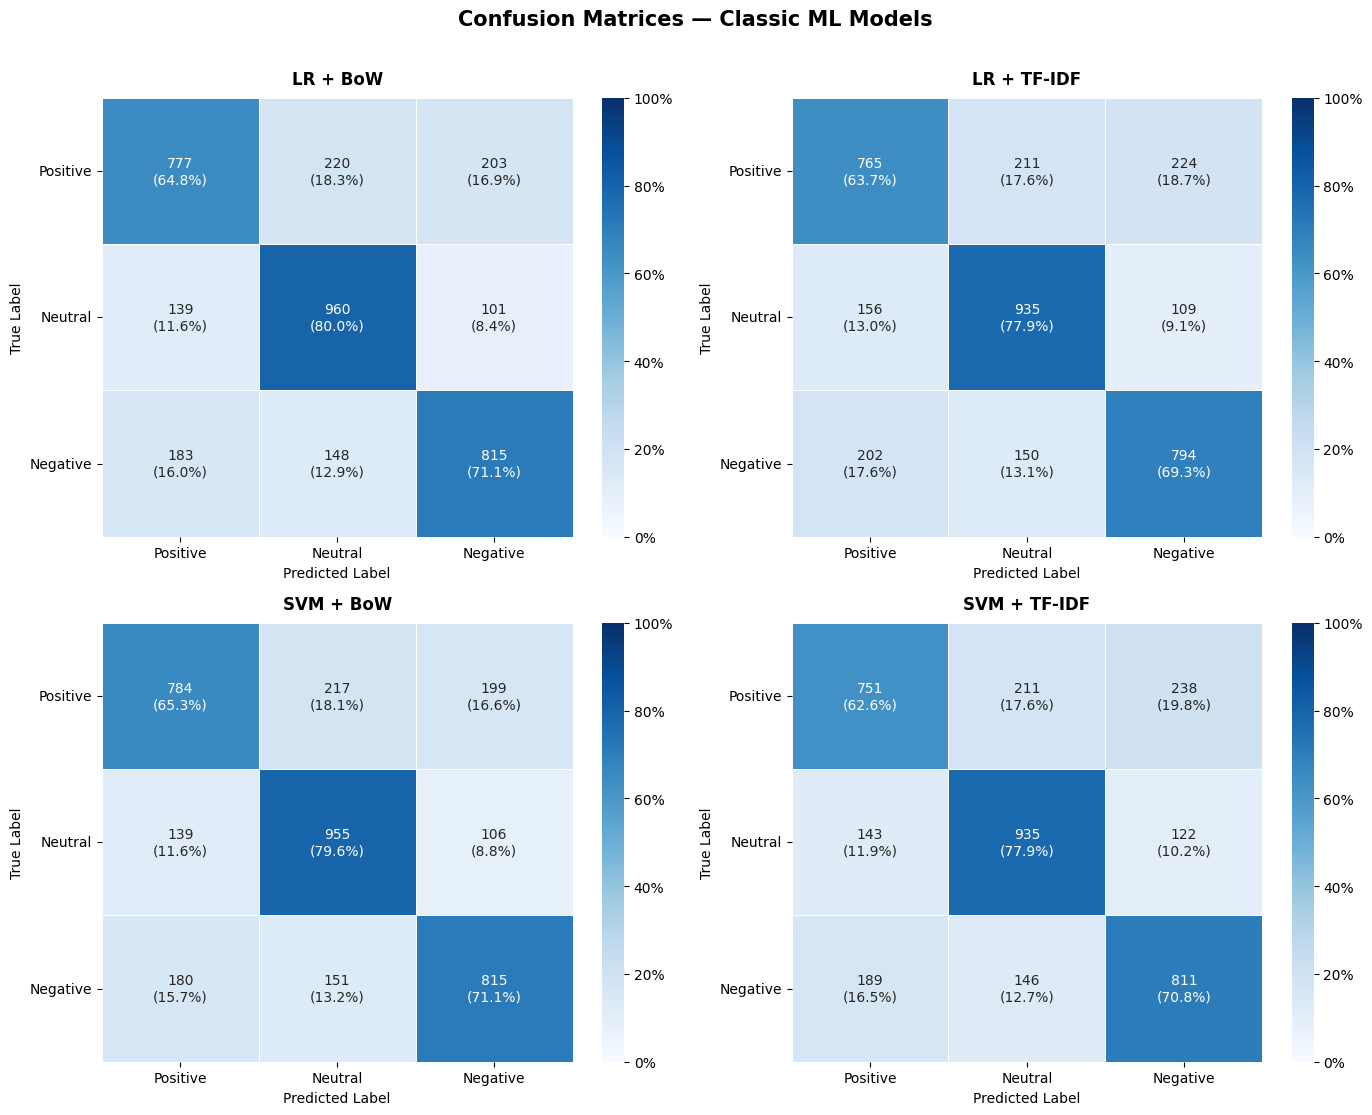

In [34]:
# ============================================
# CONFUSION MATRICES - CLASSIC ML MODELS
# ============================================
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

CLASSES = ['Positive', 'Neutral', 'Negative']
LABELS  = ['positive', 'neutral', 'negative']

models_preds = {
    'LR + BoW':     lr_bow_pred,
    'LR + TF-IDF':  lr_tfidf_pred,
    'SVM + BoW':    svm_bow_pred,
    'SVM + TF-IDF': svm_tfidf_pred,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Confusion Matrices — Classic ML Models', fontsize=15, fontweight='bold', y=1.01)

for ax, (model_name, preds) in zip(axes.flatten(), models_preds.items()):
    cm = confusion_matrix(test_labels, preds, labels=LABELS)

    # Normalised matrix for colours, raw counts for annotations
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    annot = [[f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)" for j in range(3)] for i in range(3)]

    sns.heatmap(
        cm_norm,
        annot=annot,
        fmt='',
        cmap='Blues',
        vmin=0, vmax=1,
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'format': '{x:.0%}'},
        ax=ax
    )
    ax.set_title(model_name, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# 5) MODELLING - DEEP LEARNING (LSTM)

In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer  #SFA#
from tensorflow.keras.preprocessing.sequence import pad_sequences  #SFA#
from tensorflow.keras.utils import to_categorical

sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}

y_train = np.array([sentiment_map[s] for s in train_labels])
y_val   = np.array([sentiment_map[s] for s in val_labels])
y_test  = np.array([sentiment_map[s] for s in test_labels])

# One-hot encoding
y_train = to_categorical(y_train, num_classes=3)
y_val   = to_categorical(y_val, num_classes=3)
y_test  = to_categorical(y_test, num_classes=3)

MAX_WORDS = 10000
MAX_LEN = 100
EMBEDDING_DIM = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# fit only on training setFit SOLO sul training set
tokenizer.fit_on_texts(train_dl)

train_sequences = tokenizer.texts_to_sequences(train_dl)
val_sequences   = tokenizer.texts_to_sequences(val_dl)
test_sequences  = tokenizer.texts_to_sequences(test_dl)



padded_train = pad_sequences(
    train_sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
) #NEW#

padded_val = pad_sequences(
    val_sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
) #NEW#

padded_test = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
) #NEW#

print('LSTM padded sequences shape:', padded_train.shape) #NEW#


LSTM padded sequences shape: (16546, 100)


In [37]:
# ============================================
# BiLSTM with pre-trained W2V Embedding
# ============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=200,                  # aligned with W2V vector_size
        weights=[embedding_matrix],      # pre-trained initialization
        input_length=MAX_LEN,
        trainable=True                   # fine-tuning during training
    ),

    Bidirectional(
        LSTM(
            64,
            return_sequences=False,
            recurrent_dropout=0.2
        )
    ),

    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

model.build(input_shape=(None, MAX_LEN))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n=== MODEL ARCHITECTURE (W2V-initialized Embedding) ===")
model.summary()
print(f"\nEmbedding layer initialized with W2V weights (coverage: {coverage:.1f}%)")
print(f"Trainable: fine-tuning enabled")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



=== MODEL ARCHITECTURE (W2V-initialized Embedding) ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 200)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       135,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,144,131 (8.18 MB)

 Trainable params: 2,144,131 (8.18 MB)

 Non-trainable params: 0 (0.00 B)


Embedding layer initialized with W2V weights (coverage: 77.2%)
Trainable: fine-tuning enabled


In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [38]:
# ============================================
# 7. TRAINING
# ============================================

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Training
print("\n=== START TRAINING ===")

history = model.fit(
    padded_train, y_train,
    validation_data=(padded_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)



=== START TRAINING ===
Epoch 1/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 108s 385ms/step - accuracy: 0.5128 - loss: 0.9660 - val_accuracy: 0.6255 - val_loss: 0.8176 - learning_rate: 0.0010
Epoch 2/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 146s 404ms/step - accuracy: 0.7053 - loss: 0.7130 - val_accuracy: 0.7205 - val_loss: 0.6792 - learning_rate: 0.0010
Epoch 3/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 138s 388ms/step - accuracy: 0.8115 - loss: 0.5122 - val_accuracy: 0.7171 - val_loss: 0.6856 - learning_rate: 0.0010
Epoch 4/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 109s 420ms/step - accuracy: 0.8587 - loss: 0.4012 - val_accuracy: 0.7107 - val_loss: 0.7237 - learning_rate: 0.0010
Epoch 5/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.8845 - loss: 0.3260
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
259/259 ━━━━━━━━━━━━━━━━━━━━ 133s 388ms/step - accuracy: 0.8845 - loss: 0.3261 - val_accuracy: 0.7045 - val_loss: 0.8189 - learning_rate: 0.0010
Epoch 6/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 101

In [25]:
import matplotlib.pyplot as plt

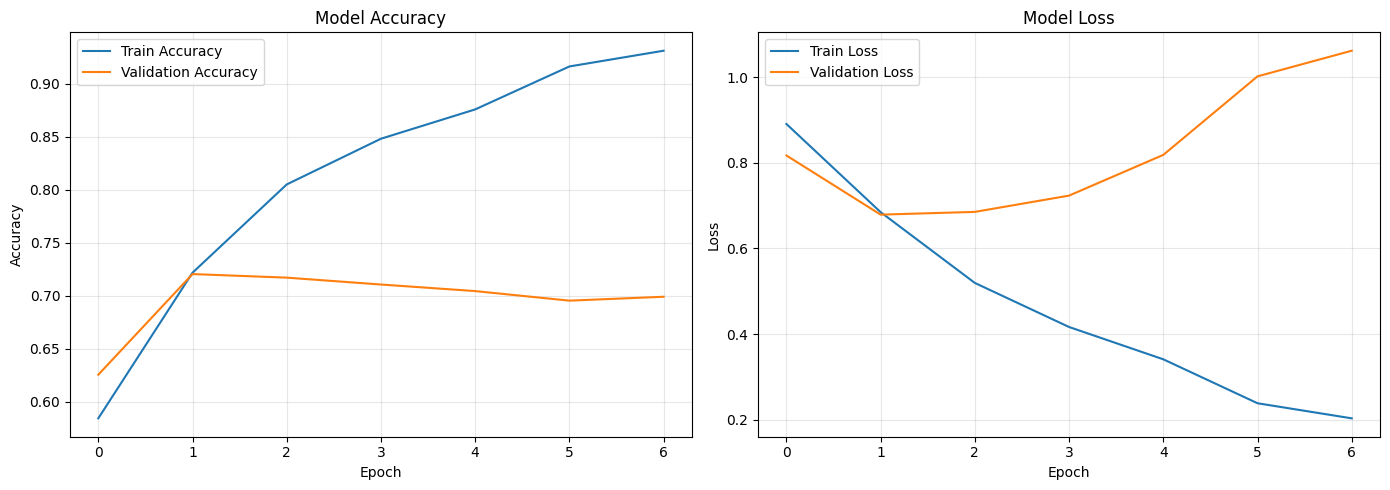

In [39]:
# ============================================
# 8. VISUALIZING TRAINING RESULTS
# ============================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step

=== TEST SET EVALUATION ===

Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.76      0.73      1146
     Neutral       0.77      0.74      0.75      1200
    Positive       0.70      0.69      0.69      1200

    accuracy                           0.73      3546
   macro avg       0.73      0.73      0.73      3546
weighted avg       0.73      0.73      0.73      3546



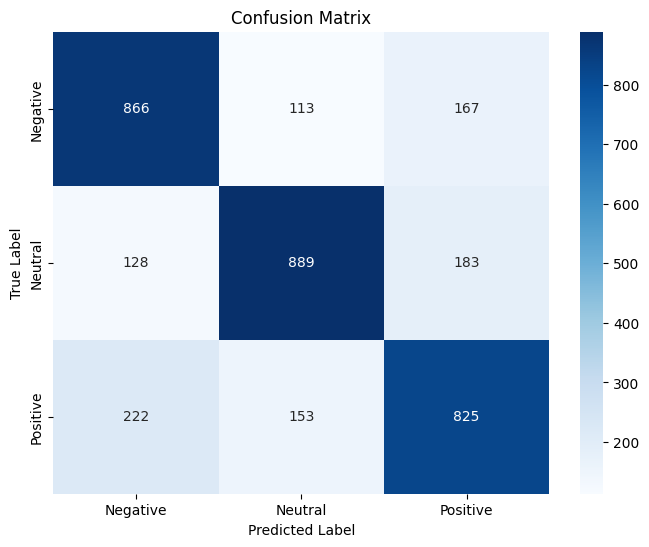


=== FINAL RESULTS ===
Test Accuracy: 72.76%
Test Loss: 0.6683


In [40]:
# ============================================
# 9. EVALUATION ON TEST SET
# ============================================

# Predictions
y_pred_probs = model.predict(padded_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Metrics
print("\n=== TEST SET EVALUATION ===")
print("\nClassification Report:")
from sklearn.metrics import classification_report # Import classification_report
print(classification_report(y_true, y_pred,
                          target_names=['Negative', 'Neutral', 'Positive']))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Final accuracy
test_loss, test_accuracy = model.evaluate(padded_test, y_test, verbose=0)
print(f"\n=== FINAL RESULTS ===")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

*Output: BiLSTM on Test Set (W2V-initialized Embedding)*

| Metric | Value |
|--------|-------|
| Test Accuracy | 72.76% |
| Test Loss | 0.6683 |
| Precision | 0.7282 |
| Recall | 0.7276 |
| F1 Score | 0.7276 |

The W2V-initialized BiLSTM is the **best-performing model overall** (F1: 0.7276), surpassing
SVM + BoW (0.7191) by ~0.009 points — a modest but consistent improvement attributable to
the pre-trained embedding initialisation. Starting from semantically informed word
representations rather than random weights allowed the model to converge to a better
solution within the same number of epochs (EarlyStopping still triggered at epoch 7,
restoring epoch 2 weights).

The per-class breakdown is notably more **balanced** than in the random-initialisation
version: Negative (f1: 0.73), Neutral (f1: 0.75), and Positive (f1: 0.69) are all closer
together, and Positive recall improved from 0.63 to 0.69 — the most significant per-class
gain, suggesting that W2V representations helped the model better distinguish mildly
positive financial language that previously blended with neutral or negative phrasing.

The training curve mirrors the previous version: overfitting sets in from epoch 3 onward,
with training accuracy reaching 81% at epoch 2 while validation accuracy peaks at 72%.
This confirms that the capacity bottleneck remains dataset size relative to model parameters,
rather than the quality of the embedding initialisation.

In [41]:
# ============================================
# TEST SET EXAMPLES
# ============================================
sentiment_names = ['Negative', 'Neutral', 'Positive']
n_examples = 15

# Random indices
np.random.seed(42)
sample_indices = np.random.choice(len(test_sentences), size=n_examples, replace=False)

print("=== TEST SET EXAMPLES ===\n")
for idx in sample_indices:
    sentence = test_sentences[idx]
    true_label = sentiment_names[y_true[idx]]
    pred_label = sentiment_names[y_pred[idx]]
    probs = y_pred_probs[idx]

    correct = "✓" if true_label == pred_label else "✗"

    print(f"Sentence: {sentence}")
    print(f"True: {true_label} | Predicted: {pred_label} {correct}")
    print(f"Probabilities → Negative: {probs[0]*100:.1f}% | Neutral: {probs[1]*100:.1f}% | Positive: {probs[2]*100:.1f}%")
    print("-" * 80)

=== TEST SET EXAMPLES ===

Sentence: Everyone's favorite trade in the stock market technology has gone the way of the dodo. Oil and value stocks are all the rage.
True: Negative | Predicted: Positive ✗
Probabilities → Negative: 17.9% | Neutral: 20.3% | Positive: 61.7%
--------------------------------------------------------------------------------
Sentence: And that 's exactly what happened on a recent weekday when an East Haven baker was brought in to remind residents about the Easter tradition of making wheat and rice pies .
True: Neutral | Predicted: Neutral ✓
Probabilities → Negative: 2.6% | Neutral: 87.6% | Positive: 9.8%
--------------------------------------------------------------------------------
Sentence: With technology-focused companies suffering a disproportionate beating during the present market rout diving into Nasdaq stocks to buy seems risky. After all the Nasdaq Composite has sustained a loss of 27% since the start of the year far wider than the other two major indi

In [42]:
# ============================================
# 10. FUNCTION TO PREDICT NEW SENTENCES
# ============================================

def predict_Sentiment(text):
    """Predict the Sentiment of a new sentence"""
    # Cleaning
    cleaned = clean_sentence(text)
    # Tokenization
    seq = tokenizer.texts_to_sequences([cleaned])
    # Padding
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    # Prediction
    pred = model.predict(padded, verbose=0)
    Sentiment_idx = np.argmax(pred)
    Sentiments = ['Negative', 'Neutral', 'Positive']
    confidence = pred[0][Sentiment_idx] * 100

    return Sentiments[Sentiment_idx], confidence

# Test with examples
print("\n=== TEST PREDICTIONS ===")
test_Sentences = [
    "The company reported strong quarterly earnings above market expectations.",
    "Revenue growth accelerated significantly compared to last year.",
    "The merger is expected to create substantial shareholder value.",
    "Operating margins improved thanks to cost reduction strategies.",
    "Analysts upgraded the stock following positive guidance.",
    "The company released its annual financial report yesterday.",
    "Shares closed unchanged after the announcement.",
    "The board approved the proposed dividend distribution.",
    "Trading volume remained stable throughout the session.",
    "The firm announced a restructuring plan for next year.",
    "The company reported a significant decline in net profit.",
    "Shares dropped sharply after weak earnings results.",
    "The firm faces increasing debt and liquidity concerns.",
    "Operating costs rose faster than expected.",
    "Analysts downgraded the stock due to poor outlook"
]

for Sentence in test_Sentences:
    Sentiment, conf = predict_Sentiment(Sentence)
    print(f"\nSentence: {Sentence}")
    print(f"Sentiment: {Sentiment} (Confidence: {conf:.2f}%)")


=== TEST PREDICTIONS ===

Sentence: The company reported strong quarterly earnings above market expectations.
Sentiment: Positive (Confidence: 89.47%)

Sentence: Revenue growth accelerated significantly compared to last year.
Sentiment: Positive (Confidence: 55.15%)

Sentence: The merger is expected to create substantial shareholder value.
Sentiment: Neutral (Confidence: 86.95%)

Sentence: Operating margins improved thanks to cost reduction strategies.
Sentiment: Negative (Confidence: 76.81%)

Sentence: Analysts upgraded the stock following positive guidance.
Sentiment: Positive (Confidence: 83.93%)

Sentence: The company released its annual financial report yesterday.
Sentiment: Neutral (Confidence: 94.28%)

Sentence: Shares closed unchanged after the announcement.
Sentiment: Neutral (Confidence: 49.75%)

Sentence: The board approved the proposed dividend distribution.
Sentiment: Neutral (Confidence: 91.18%)

Sentence: Trading volume remained stable throughout the session.
Sentiment:

        FINAL REPORT - MODELS COMPARISON
       Model  Accuracy  Precision  Recall  F1 Score
      BiLSTM    0.7276     0.7282  0.7276    0.7276
   SVM + BoW    0.7202     0.7200  0.7202    0.7191
    LR + BoW    0.7197     0.7193  0.7197    0.7183
SVM + TF-IDF    0.7042     0.7034  0.7042    0.7028
 LR + TF-IDF    0.7033     0.7024  0.7033    0.7022

 Best model according to F1 Score: BiLSTM (0.7276)


/tmp/ipython-input-554964728.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=report_df, x='Model', y='F1 Score', ax=axes[0], palette='Blues_d')


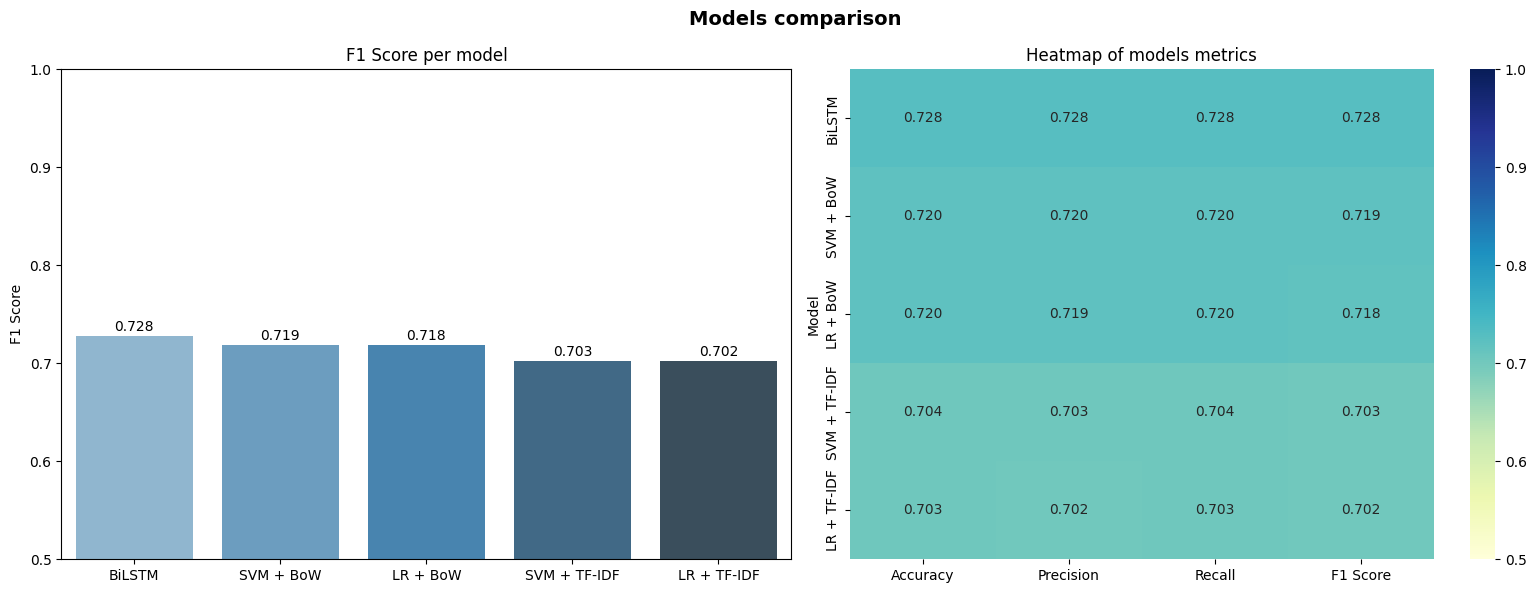

In [43]:
# ============================================
# FINAL MODELS COMPARISON
# ============================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Predictions already computed ---
all_results = {
    'LR + BoW':    lr_bow_pred,
    'LR + TF-IDF': lr_tfidf_pred,
    'SVM + BoW':   svm_bow_pred,
    'SVM + TF-IDF': svm_tfidf_pred,
}

# For uniformity: convert LSTM one-shot into strings
lstm_pred_labels = np.array([['negative', 'neutral', 'positive'][i] for i in y_pred])
all_results['BiLSTM'] = lstm_pred_labels
true_labels_lstm = np.array([['negative', 'neutral', 'positive'][i] for i in y_true])

# --- Table of metrics ---
rows = []
for model_name, preds in all_results.items():
    # LSTM has different true labels (one-hot), others use test_labels
    true = true_labels_lstm if model_name == 'BiLSTM' else test_labels

    rows.append({
        'Model': model_name,
        'Accuracy':  round(accuracy_score(true, preds), 4),
        'Precision': round(precision_score(true, preds, average='weighted'), 4),
        'Recall':    round(recall_score(true, preds, average='weighted'), 4),
        'F1 Score':  round(f1_score(true, preds, average='weighted'), 4),
    })

report_df = pd.DataFrame(rows).sort_values('F1 Score', ascending=False).reset_index(drop=True)

print("=" * 65)
print("        FINAL REPORT - MODELS COMPARISON")
print("=" * 65)
print(report_df.to_string(index=False))
print("=" * 65)
print(f"\n Best model according to F1 Score: {report_df.iloc[0]['Model']} "
      f"({report_df.iloc[0]['F1 Score']:.4f})")

# --- graphic visualization ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Models comparison', fontsize=14, fontweight='bold')

# 1st plot: F1 Score per model
sns.barplot(data=report_df, x='Model', y='F1 Score', ax=axes[0], palette='Blues_d')
axes[0].set_title('F1 Score per model')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_xlabel('')
for i, v in enumerate(report_df['F1 Score']):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

# 2nd plot: heatmap of all metrics
heatmap_data = report_df.set_index('Model')[metrics]
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0.5, vmax=1.0, ax=axes[1])
axes[1].set_title('Heatmap of models metrics')

plt.tight_layout()
plt.show()

*Final comparison on models*

| Model | Accuracy | Precision | Recall | F1 Score |
|-------|----------|-----------|--------|----------|
| **BiLSTM** | **0.7276** | **0.7282** | **0.7276** | **0.7276** |
| SVM + BoW | 0.7202 | 0.7200 | 0.7202 | 0.7191 |
| LR + BoW | 0.7197 | 0.7193 | 0.7197 | 0.7183 |
| SVM + TF-IDF | 0.7042 | 0.7034 | 0.7042 | 0.7028 |
| LR + TF-IDF | 0.7033 | 0.7024 | 0.7033 | 0.7022 |

The **best model is BiLSTM with W2V-initialized Embedding** (F1: 0.7276), demonstrating
that the integration of pre-trained word representations provides a measurable advantage
over both random-initialisation deep learning and classical bag-of-words approaches.

The two-tier structure observed among classical models is confirmed: both BoW-based models
consistently outperform TF-IDF-based ones by ~1.6 points in F1, regardless of the
classifier, indicating that the vectorisation choice matters more than the algorithm on
this corpus.

BiLSTM does not outperform classical models when trained from random initialisation, but
does so once the embedding layer is seeded with domain-relevant W2V weights. This is
consistent with the literature: on short sentences and specialised vocabulary, sequential
models need a stronger initialisation signal to express their advantage over bag-of-words
approaches, which typically emerges with longer texts or more ambiguous language.

Potential further improvements include fine-tuning a transformer-based model pre-trained
on financial text (e.g. FinBERT), or incorporating domain-specific sentiment lexicons
such as the Loughran-McDonald financial dictionary.